In [5]:
## Phần 1: Khởi tạo và đọc dữ liệu
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc file dữ liệu vào DataFrame
df = pd.read_csv('ecommerce_sales_data.csv')

# 2. Hiển thị 7 dòng đầu tiên và 5 dòng cuối cùng
print("--- 7 dòng đầu tiên ---")
display(df.head(7)) # Dùng hàm display() trong Colab nhìn bảng sẽ đẹp hơn print()
print("\n--- 5 dòng cuối cùng ---")
display(df.tail(5))

# 3. Thông tin tổng quan của cấu trúc dữ liệu
print("\n--- Thông tin tổng quan ---")
df.info()

# 4. Thống kê mô tả các cột dữ liệu dạng số
print("\n--- Thống kê mô tả ---")
display(df.describe())

--- 7 dòng đầu tiên ---


,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region
0,ORD0001,2025-11-24,CUST027,Clothing,Jeans,6,93.20,0.12,Central
1,ORD0002,2025-02-27,CUST025,Electronics,Smartphone,10,134.67,NaN,South
2,ORD0003,2025-01-13,CUST025,Books,Machine Learning Intro,9,178.20,0.04,North
3,ORD0004,2025-05-21,CUST002,Home & Kitchen,Coffee Maker,3,199.86,0.01,North
4,ORD0005,2025-05-06,CUST008,Electronics,Laptop,7,144.85,0.17,North
5,ORD0006,2025-04-25,CUST027,Electronics,Laptop,3,138.23,NaN,Central
6,ORD0007,2025-03-13,CUST002,Books,Data Science Handbook,1,71.97,0.04,South



--- 5 dòng cuối cùng ---


,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region
95,ORD0096,2025-12-19,CUST021,Books,Python for Data Analysis,4,73.96,0.14,North
96,ORD0097,2025-10-13,CUST010,Home & Kitchen,Microwave,7,73.63,0.12,North
97,ORD0098,2025-04-23,NaN,Books,Python for Data Analysis,7,136.39,NaN,North
98,ORD0099,2025-12-17,CUST021,Home & Kitchen,Microwave,3,18.42,0.02,Central
99,ORD0100,2025-06-16,CUST017,Home & Kitchen,Coffee Maker,10,107.48,NaN,Central



--- Thông tin tổng quan ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OrderID           100 non-null    object 
 1   Date              100 non-null    object 
 2   CustomerID        95 non-null     object 
 3   Product_Category  100 non-null    object 
 4   Product_Name      100 non-null    object 
 5   Quantity          100 non-null    int64  
 6   UnitPrice         100 non-null    float64
 7   Discount          65 non-null     float64
 8   Region            100 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 7.2+ KB

--- Thống kê mô tả ---


,Quantity,UnitPrice,Discount
count,100.000000,100.000000,65.000000
mean,5.150000,153.546200,0.141385
std,2.896794,77.360231,0.079134
min,-5.000000,11.610000,0.010000
25%,3.000000,84.445000,0.080000
50%,5.000000,154.880000,0.150000
75%,7.000000,215.792500,0.210000
max,10.000000,296.490000,0.300000


In [7]:
##Phần 2: Khám phá và Làm sạch dữ liệu
# 1. Kiểm tra số lượng giá trị bị thiếu ở mỗi cột
print("Số lượng giá trị thiếu ban đầu:")
print(df.isna().sum())

# 2. Xử lý giá trị thiếu ở cột Discount (thay bằng 0)
df['Discount'] = df['Discount'].fillna(0)

# 3. Xử lý giá trị thiếu ở cột CustomerID (thay bằng 'GUEST')
df['CustomerID'] = df['CustomerID'].fillna('GUEST')

# 4. Kiểm tra lại để đảm bảo không còn giá trị thiếu
print("\nSố lượng giá trị thiếu sau khi xử lý:")
print(df.isna().sum())

# 5. Chuyển đổi kiểu dữ liệu cột Date sang datetime
df['Date'] = pd.to_datetime(df['Date'])

# 6. Kiểm tra và loại bỏ dòng trùng lặp
so_dong_trung = df.duplicated().sum()
print(f"\nSố dòng trùng lặp toàn bộ: {so_dong_trung}")
if so_dong_trung > 0:
    df = df.drop_duplicates()
    print("Đã loại bỏ các dòng trùng lặp.")

Số lượng giá trị thiếu ban đầu:
OrderID             0
Date                0
CustomerID          0
Product_Category    0
Product_Name        0
Quantity            0
UnitPrice           0
Discount            0
Region              0
dtype: int64

Số lượng giá trị thiếu sau khi xử lý:
OrderID             0
Date                0
CustomerID          0
Product_Category    0
Product_Name        0
Quantity            0
UnitPrice           0
Discount            0
Region              0
dtype: int64

Số dòng trùng lặp toàn bộ: 0


In [9]:
##Phần 3: Trích xuất và Biến đổi dữ liệu (Feature Engineering)
# 1. Tạo cột Revenue (Doanh thu)
df['Revenue'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount'])

# 2. Trích xuất Năm (Year)
df['Year'] = df['Date'].dt.year

# 3. Trích xuất Tháng (Month)
df['Month'] = df['Date'].dt.month

# 4. Trích xuất Ngày trong tuần (Day of Week) - Hiển thị tên ngày tiếng Anh
df['DayOfWeek'] = df['Date'].dt.day_name()

# 5. Tạo cột phân loại Price_Segment
def get_price_segment(price):
    if price >= 150:
        return 'High'
    elif price >= 50:
        return 'Medium'
    else:
        return 'Low'

df['Price_Segment'] = df['UnitPrice'].apply(get_price_segment)

# Hiển thị vài dòng để kiểm tra kết quả biến đổi
display(df[['Date', 'Year', 'Month', 'DayOfWeek', 'UnitPrice', 'Price_Segment', 'Revenue']].head())

,Date,Year,Month,DayOfWeek,UnitPrice,Price_Segment,Revenue
0,2025-11-24,2025,11,Monday,93.20,Medium,492.0960
1,2025-02-27,2025,2,Thursday,134.67,Medium,1346.7000
2,2025-01-13,2025,1,Monday,178.20,High,1539.6480
3,2025-05-21,2025,5,Wednesday,199.86,High,593.5842
4,2025-05-06,2025,5,Tuesday,144.85,Medium,841.5785


In [11]:
##Phần 4: Lọc và Truy vấn dữ liệu
# 1. Đơn hàng khu vực 'North' có doanh thu > 300
north_high_revenue = df[(df['Region'] == 'North') & (df['Revenue'] > 300)]
print("1. Đơn hàng North có doanh thu > 300:")
display(north_high_revenue)

# 2. Số đơn hàng 'Electronics' không giảm giá
electronics_no_discount = df[(df['Product_Category'] == 'Electronics') & (df['Discount'] == 0)]
print(f"\n2. Số lượng đơn hàng Electronics không giảm giá: {len(electronics_no_discount)}")

# 3. Đơn hàng mua từ tháng 3 đến tháng 6
spring_summer_orders = df[df['Month'].between(3, 6)]
print("\n3. Số lượng đơn hàng từ tháng 3 đến tháng 6:", len(spring_summer_orders))

# 4. Top 10 đơn hàng có doanh thu cao nhất (OrderID, Product_Name, Revenue)
top_10_revenue = df.nlargest(10, 'Revenue')[['OrderID', 'Product_Name', 'Revenue']]
print("\n4. Top 10 đơn hàng doanh thu cao nhất:")
display(top_10_revenue)

# 5. Chi tiết đơn hàng có số lượng (Quantity) mua nhiều nhất
max_quantity_order = df[df['Quantity'] == df['Quantity'].max()]
print("\n5. Đơn hàng có số lượng mua nhiều nhất:")
display(max_quantity_order)

1. Đơn hàng North có doanh thu > 300:


,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region,Revenue,Year,Month,DayOfWeek,Price_Segment
2,ORD0003,2025-01-13,CUST025,Books,Machine Learning Intro,9,178.20,0.04,North,1539.6480,2025,1,Monday,High
3,ORD0004,2025-05-21,CUST002,Home & Kitchen,Coffee Maker,3,199.86,0.01,North,593.5842,2025,5,Wednesday,High
4,ORD0005,2025-05-06,CUST008,Electronics,Laptop,7,144.85,0.17,North,841.5785,2025,5,Tuesday,Medium
25,ORD0026,2025-10-07,GUEST,Books,Data Science Handbook,6,130.19,0.00,North,781.1400,2025,10,Tuesday,Medium
31,ORD0032,2025-01-04,CUST018,Electronics,Headphones,7,200.26,0.20,North,1121.4560,2025,1,Saturday,High
33,ORD0034,2025-12-24,CUST009,Electronics,Headphones,8,227.78,0.02,North,1785.7952,2025,12,Wednesday,High
36,ORD0037,2025-05-23,CUST014,Electronics,Monitor,8,133.29,0.26,North,789.0768,2025,5,Friday,Medium
37,ORD0038,2025-03-21,CUST029,Electronics,Smartphone,6,61.01,0.04,North,351.4176,2025,3,Friday,Medium
44,ORD0045,2025-07-03,CUST016,Clothing,T-Shirt,6,242.41,0.21,North,1149.0234,2025,7,Thursday,High
45,ORD0046,2025-06-26,CUST003,Books,Python for Data Analysis,5,203.60,0.22,North,794.0400,2025,6,Thursday,High



2. Số lượng đơn hàng Electronics không giảm giá: 8

3. Số lượng đơn hàng từ tháng 3 đến tháng 6: 33

4. Top 10 đơn hàng doanh thu cao nhất:


,OrderID,Product_Name,Revenue
83,ORD0084,T-Shirt,2584.5000
61,ORD0062,Laptop,2251.2730
49,ORD0050,Coffee Maker,2223.2628
51,ORD0052,Coffee Maker,1967.3100
33,ORD0034,Headphones,1785.7952
15,ORD0016,Jeans,1780.8480
89,ORD0090,Coffee Maker,1730.4000
80,ORD0081,Laptop,1601.7120
2,ORD0003,Machine Learning Intro,1539.6480
8,ORD0009,T-Shirt,1530.3576



5. Đơn hàng có số lượng mua nhiều nhất:


,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region,Revenue,Year,Month,DayOfWeek,Price_Segment
1,ORD0002,2025-02-27,CUST025,Electronics,Smartphone,10,134.67,0.00,South,1346.700,2025,2,Thursday,Medium
17,ORD0018,2025-04-30,CUST011,Home & Kitchen,Microwave,10,205.11,0.28,South,1476.792,2025,4,Wednesday,High
57,ORD0058,2025-11-13,CUST003,Books,Data Science Handbook,10,147.66,0.10,Central,1328.940,2025,11,Thursday,Medium
61,ORD0062,2025-12-27,CUST015,Electronics,Laptop,10,232.09,0.03,Central,2251.273,2025,12,Saturday,High
66,ORD0067,2025-05-29,CUST001,Electronics,Laptop,10,92.86,0.00,North,928.600,2025,5,Thursday,Medium
83,ORD0084,2025-11-28,CUST001,Clothing,T-Shirt,10,258.45,0.00,Central,2584.500,2025,11,Friday,High
99,ORD0100,2025-06-16,CUST017,Home & Kitchen,Coffee Maker,10,107.48,0.00,Central,1074.800,2025,6,Monday,Medium


In [13]:
##Phần 5: Phân tích, Gom nhóm và Tổng hợp
# 1. Tổng doanh thu theo khu vực
revenue_by_region = df.groupby('Region')['Revenue'].sum()
print("1. Tổng doanh thu theo khu vực:")
display(revenue_by_region)
print(f"-> Khu vực mang lại doanh thu cao nhất là: {revenue_by_region.idxmax()}")

# 2. Trung bình Quantity và UnitPrice theo Product_Category
avg_stats_by_category = df.groupby('Product_Category')[['Quantity', 'UnitPrice']].mean()
print("\n2. Trung bình số lượng và đơn giá theo danh mục:")
display(avg_stats_by_category)

# 3. Thống kê tổng số lượng đơn hàng theo tháng
orders_by_month = df.groupby('Month').size()
print("\n3. Số lượng đơn hàng theo tháng:")
display(orders_by_month)
print(f"-> Tháng ghi nhận số lượng mua nhiều nhất là tháng: {orders_by_month.idxmax()}")

# 4. Top 3 khách hàng chi tiêu cao nhất (Loại trừ 'GUEST')
real_customers = df[df['CustomerID'] != 'GUEST']
top_3_customers = real_customers.groupby('CustomerID')['Revenue'].sum().nlargest(3)
print("\n4. Top 3 khách hàng (không tính GUEST) chi tiêu cao nhất:")
display(top_3_customers)


1. Tổng doanh thu theo khu vực:


,Revenue
Region,
Central,30679.9509
North,23579.3016
South,18995.3702


-> Khu vực mang lại doanh thu cao nhất là: Central

2. Trung bình số lượng và đơn giá theo danh mục:


,Quantity,UnitPrice
Product_Category,,
Books,5.071429,124.435000
Clothing,5.321429,167.446786
Electronics,5.551724,166.513103
Home & Kitchen,4.620690,141.211724



3. Số lượng đơn hàng theo tháng:


,0
Month,
1,7
2,12
3,7
4,11
5,11
6,4
7,9
8,7
9,1


-> Tháng ghi nhận số lượng mua nhiều nhất là tháng: 2

4. Top 3 khách hàng (không tính GUEST) chi tiêu cao nhất:


,Revenue
CustomerID,
CUST025,5505.3496
CUST004,5033.4404
CUST017,4553.5066


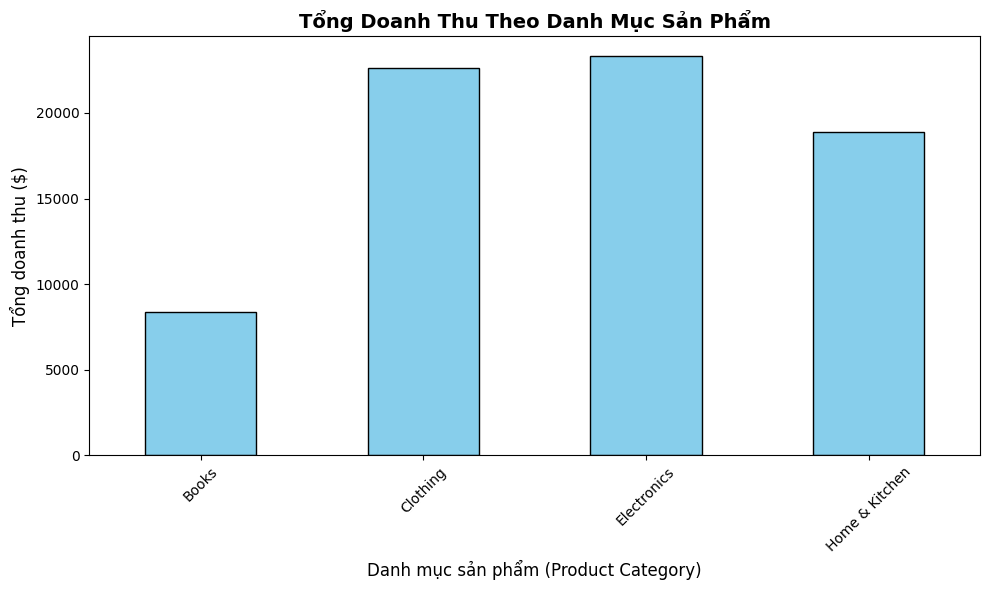

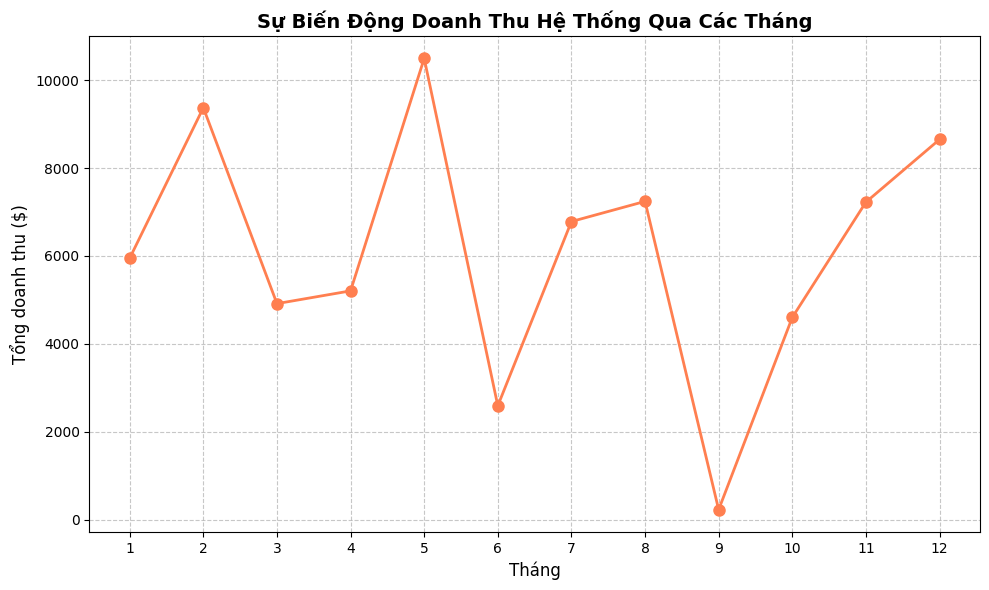

In [14]:
##Phần 6: Trực quan hóa dữ liệu cơ bản
# 1. Vẽ biểu đồ cột: Tổng doanh thu theo Danh mục sản phẩm
revenue_by_category = df.groupby('Product_Category')['Revenue'].sum()

plt.figure(figsize=(10, 6))
revenue_by_category.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Tổng Doanh Thu Theo Danh Mục Sản Phẩm', fontsize=14, fontweight='bold')
plt.xlabel('Danh mục sản phẩm (Product Category)', fontsize=12)
plt.ylabel('Tổng doanh thu ($)', fontsize=12)
plt.xticks(rotation=45) # Xoay nhãn trục X để dễ đọc
plt.tight_layout()
plt.show()

# 2. Vẽ biểu đồ đường: Sự biến động của tổng doanh thu qua các tháng
revenue_by_month = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(10, 6))
revenue_by_month.plot(kind='line', marker='o', color='coral', linewidth=2, markersize=8)

plt.title('Sự Biến Động Doanh Thu Hệ Thống Qua Các Tháng', fontsize=14, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Tổng doanh thu ($)', fontsize=12)
plt.xticks(range(1, 13)) # Đảm bảo trục X hiển thị các số từ 1 đến 12
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()